Phase 2 : Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look clean
plt.style.use("ggplot")

# Display all columns if needed
pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv("../data/Used_Car_Price_Prediction.csv")

In [3]:
df.head()


,car_name,yr_mfr,fuel_type,kms_run,sale_price,city,times_viewed,body_type,transmission,variant,assured_buy,registered_city,registered_state,is_hot,rto,source,make,model,car_availability,total_owners,broker_quote,original_price,car_rating,ad_created_on,fitness_certificate,emi_starts_from,booking_down_pymnt,reserved,warranty_avail
0,maruti swift,2015,petrol,8063,386399,noida,18715,hatchback,manual,lxi opt,True,delhi,delhi,True,dl6c,inperson_sale,maruti,swift,in_stock,2,397677,404177.0,great,2021-04-04T07:09:18.583,True,8975,57960,False,False
1,maruti alto 800,2016,petrol,23104,265499,noida,2676,hatchback,manual,lxi,True,noida,uttar pradesh,True,up16,inperson_sale,maruti,alto 800,in_stock,1,272935,354313.0,great,2021-03-22T14:07:32.833,True,6167,39825,False,False
2,hyundai grand i10,2017,petrol,23402,477699,noida,609,hatchback,manual,sports 1.2 vtvt,True,agra,uttar pradesh,True,up80,inperson_sale,hyundai,grand i10,in_stock,1,469605,NaN,great,2021-03-20T05:36:31.311,True,11096,71655,False,False
3,maruti swift,2013,diesel,39124,307999,noida,6511,hatchback,manual,vdi,True,delhi,delhi,True,dl1c,inperson_sale,maruti,swift,in_stock,1,294262,374326.0,great,2021-01-21T12:59:19.299,True,7154,46200,False,False
4,hyundai grand i10,2015,petrol,22116,361499,noida,3225,hatchback,manual,magna 1.2 vtvt,False,new delhi,delhi,True,dl12,inperson_sale,hyundai,grand i10,in_stock,1,360716,367216.0,great,2021-04-01T13:33:40.733,True,8397,54225,False,False


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (7400, 29)


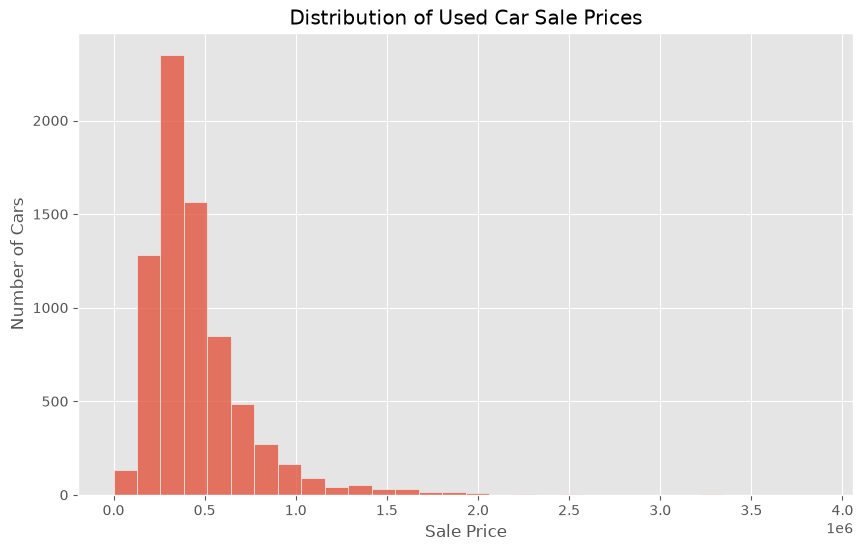

In [5]:
plt.figure(figsize=(10,6))

sns.histplot(df["sale_price"], bins=30)

plt.title("Distribution of Used Car Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Cars")

plt.show()

In [6]:
df["sale_price"].describe()

count    7.400000e+03
mean     4.548892e+05
std      2.827023e+05
min      0.000000e+00
25%      2.811740e+05
50%      3.824490e+05
75%      5.401490e+05
max      3.866000e+06
Name: sale_price, dtype: float64

In [7]:
print("Skewness:", df["sale_price"].skew())

Skewness: 2.769917550518579


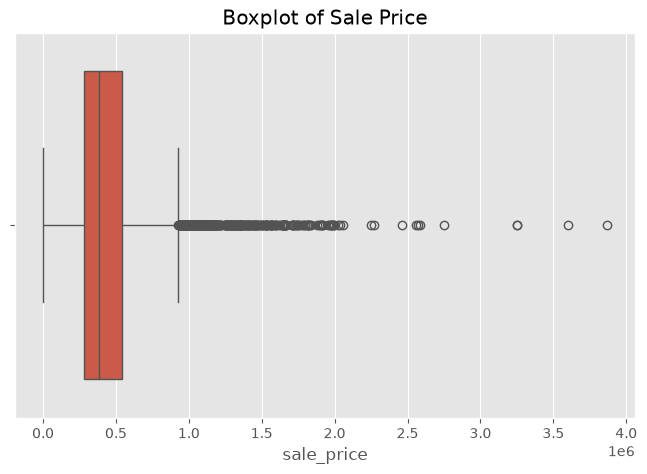

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["sale_price"])

plt.title("Boxplot of Sale Price")

plt.show()

 Observation: Sale Price Distribution

- The histogram shows how used car sale prices are distributed.
- It helps identify whether the target variable is normally distributed or skewed.
- It also provides an initial indication of possible outliers.
- Understanding the target distribution is important before training regression models.

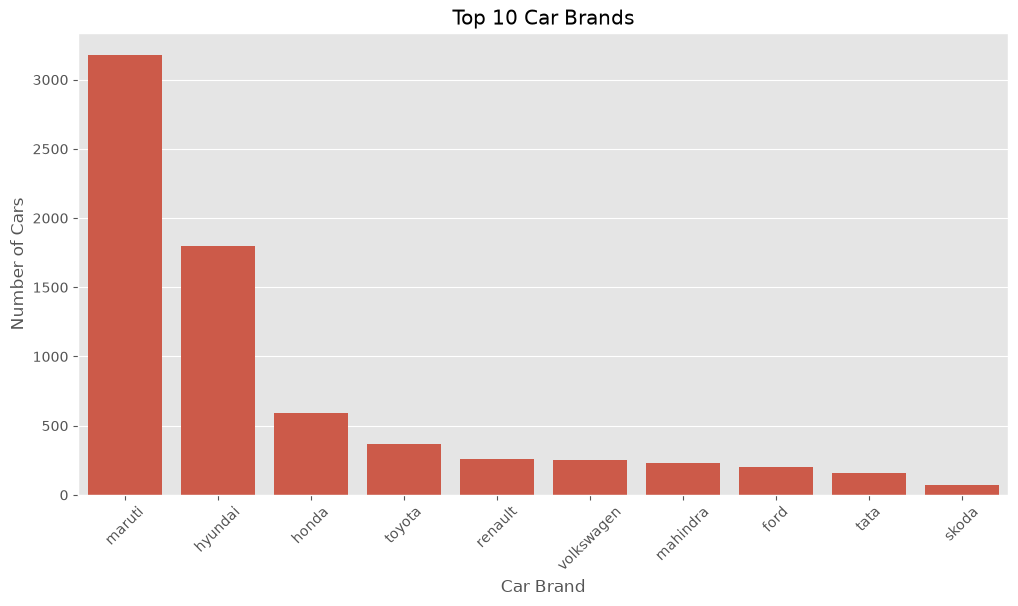

In [9]:
plt.figure(figsize=(12,6))

top_brands = df["make"].value_counts().head(10)

sns.barplot(x=top_brands.index, y=top_brands.values)

plt.title("Top 10 Car Brands")
plt.xlabel("Car Brand")
plt.ylabel("Number of Cars")

plt.xticks(rotation=45)

plt.show()

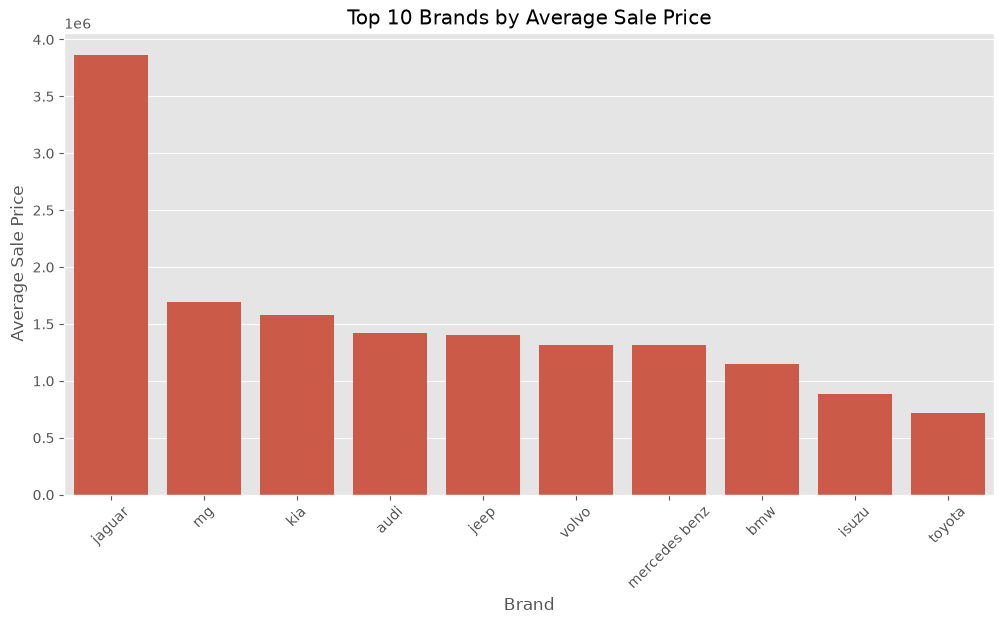

In [10]:
plt.figure(figsize=(12,6))

brand_price = (
    df.groupby("make")["sale_price"]
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

sns.barplot(x=brand_price.index, y=brand_price.values)

plt.title("Top 10 Brands by Average Sale Price")
plt.xlabel("Brand")
plt.ylabel("Average Sale Price")

plt.xticks(rotation=45)

plt.show()

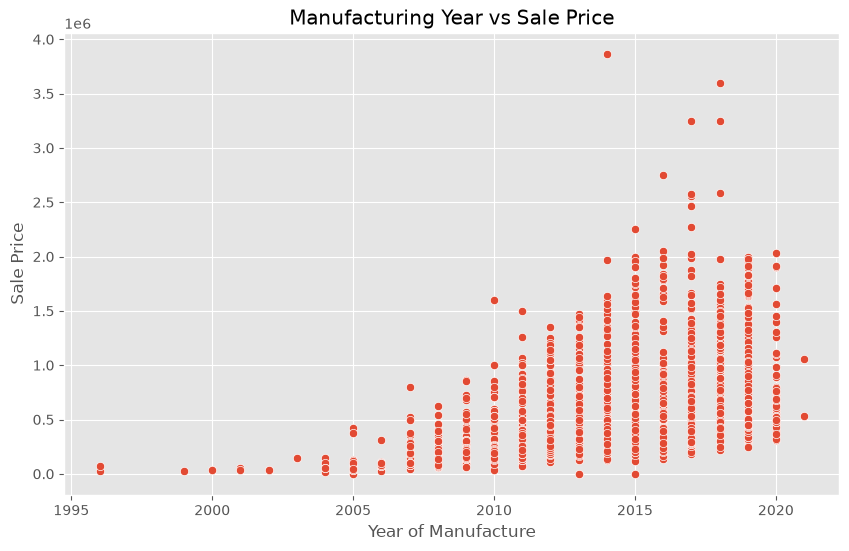

In [11]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["yr_mfr"],
    y=df["sale_price"]
)

plt.title("Manufacturing Year vs Sale Price")
plt.xlabel("Year of Manufacture")
plt.ylabel("Sale Price")

plt.show()

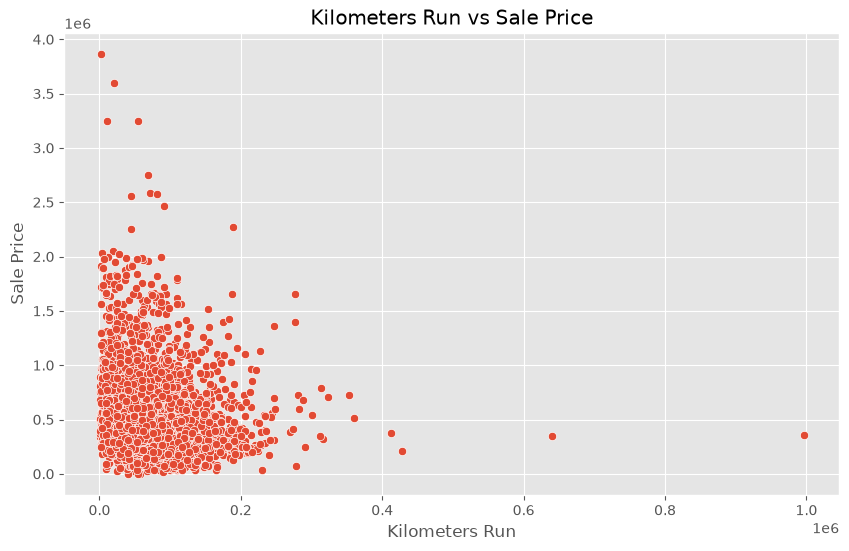

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["kms_run"],
    y=df["sale_price"]
)

plt.title("Kilometers Run vs Sale Price")
plt.xlabel("Kilometers Run")
plt.ylabel("Sale Price")

plt.show()

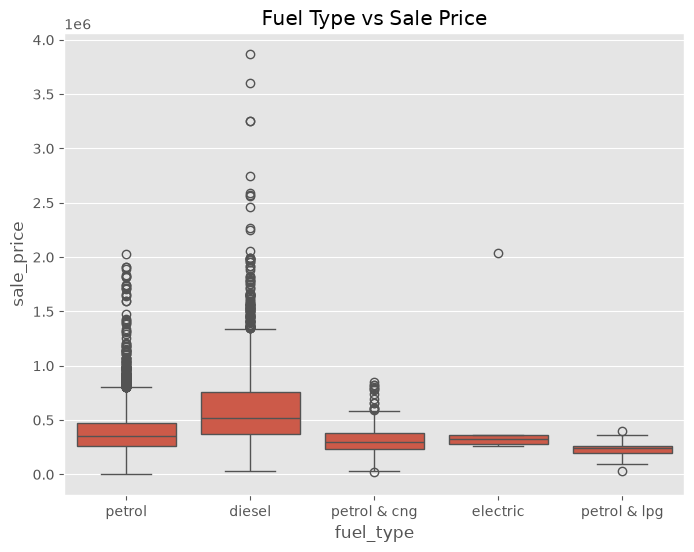

In [13]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="fuel_type",
    y="sale_price",
    data=df
)

plt.title("Fuel Type vs Sale Price")

plt.show()

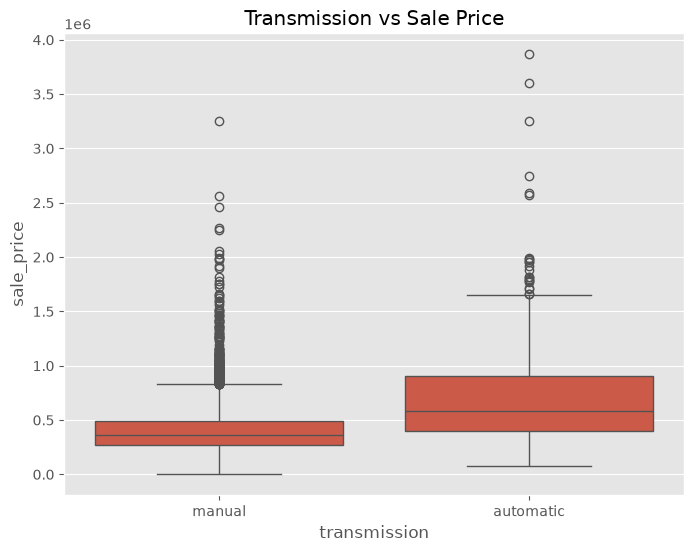

In [14]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="transmission",
    y="sale_price",
    data=df
)

plt.title("Transmission vs Sale Price")

plt.show()

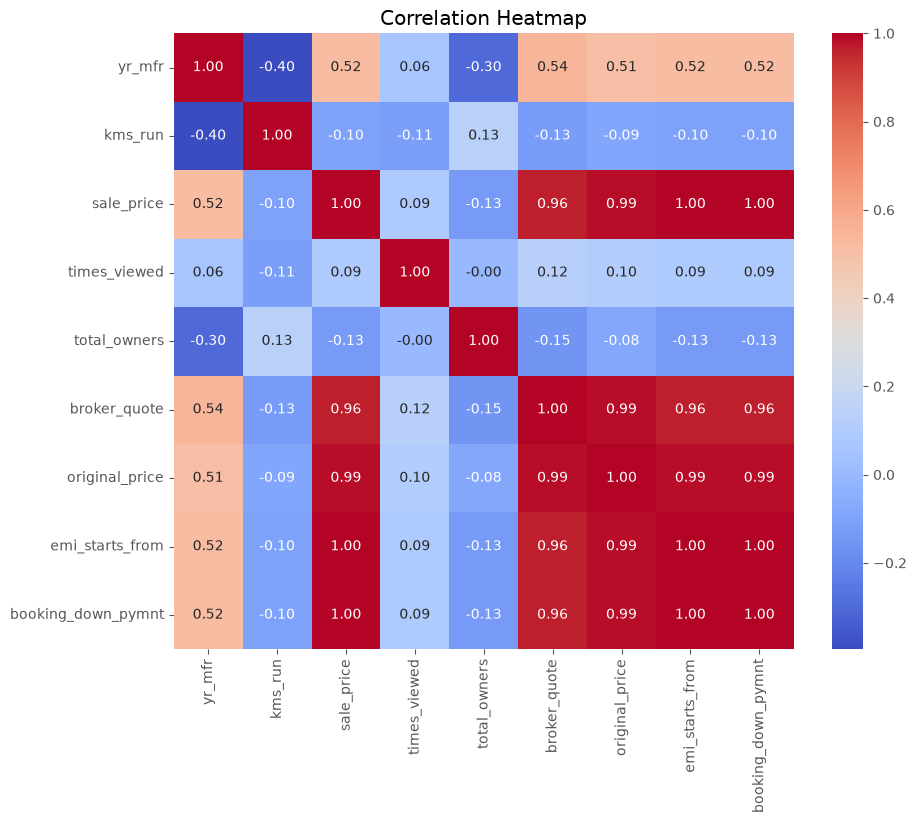

In [15]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()